# Financial Econometrics Project 1
## Time Series Challenges in Financial Data Using Apple Inc. Stock Prices(2018-2025)


# Table of Contents

1. Introduction and Objectives
2. Data Collection and Description
3. Data Cleaning and Preparation
4. Exploratory Data Analysis
5. Time Series Challenges:

     - Skewness
     - Outliers
     - Volatility
     - Overfitting

6. Statistical Analysis and Interpretation
7. Graphs and Visualizations
8. Discussion of Findings
9. Conclusion
10. References

## Introduction

Financial time series analysis plays an important role in modern finance, investment analysis, and forecasting. However, financial datasets often contain statistical challenges such as non-normality, skewness, volatility clustering, and outliers, which may affect the reliability of econometric models. This project investigates these challenges using Apple Inc. stock price data collected from Yahoo Finance between 2018 and 2025. Using Python and econometric techniques, the study demonstrates how financial data can be prepared, analyzed, and interpreted to improve financial modeling and decision-making.

## Objectives of the Study

- To collect historical stock price data for Apple Inc. using the yfinance API.
- To clean, organize, and prepare financial time series data for analysis.
- To compute and analyze stock returns and log returns.
- To investigate statistical challenges in financial time series data, including skewness, outliers, volatility, and overfitting.
- To visualize and interpret the behavior of financial data using graphs and descriptive statistics.
- To evaluate how time series challenges affect financial modeling and forecasting.
- To demonstrate the importance of proper data preparation and econometric analysis in financial decision-making.

In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Collection

The dataset is obtained using the yfinance API, which retrieves historical stock data from Yahoo Finance.

In [54]:
ticker = "AAPL"
path = r"C:\Users\tamia\PycharmProjects\Time_Series & Financial_Econometrics_Project1"

# 2. Download the data
# Note: I changed the end date to today because 2025 hasn't happened yet!
import yfinance as yf
data = yf.download(ticker, start="2018-01-01", end="2026-01-01")
data['Returns'] = data['Close'].pct_change()


import os
if data.empty:
    print("Error: No data was downloaded. Check your internet connection or ticker symbol.")
else:
    # 4. Create directory and save
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, "raw_AAPL.csv")
    data.to_csv(file_path)

    print(f"Success! Raw data saved to: {file_path}")
    print(data.head())

[*********************100%***********************]  1 of 1 completed

Success! Raw data saved to: C:\Users\tamia\PycharmProjects\Time_Series & Financial_Econometrics_Project1\raw_AAPL.csv
Price           Close       High        Low       Open     Volume   Returns
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL          
Date                                                                       
2018-01-02  40.304176  40.313537  39.602258  39.812835  102223600       NaN
2018-01-03  40.297153  40.839972  40.233983  40.367346  118071600 -0.000174
2018-01-04  40.484325  40.587274  40.262052  40.369677   89738400  0.004645
2018-01-05  40.945278  41.031847  40.489031  40.580281   94640000  0.011386
2018-01-08  40.793182  41.087987  40.694911  40.793182   82271200 -0.003715


## Data Inspection

Initial exploration of the dataset to understand structure and identify potential issues.

In [55]:
print(data.info())
print(data.describe())
print(data.isnull().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 2011 entries, 2018-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2011 non-null   float64
 1   (High, AAPL)    2011 non-null   float64
 2   (Low, AAPL)     2011 non-null   float64
 3   (Open, AAPL)    2011 non-null   float64
 4   (Volume, AAPL)  2011 non-null   int64  
 5   (Returns, )     2010 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 110.0 KB
None
Price         Close         High          Low         Open        Volume  \
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL   
count   2011.000000  2011.000000  2011.000000  2011.000000  2.011000e+03   
mean     135.389681   136.756030   133.888453   135.259052  9.442735e+07   
std       66.752842    67.332882    66.102209    66.687310  5.447156e+07   
min       33.768082    34.606406    33.722959    34.193179  1.791060e+07   
25%       64.3

## Data Cleaning

The dataset was prepared by removing missing values, eliminating duplicate records, and ensuring correct data types.
The data was also sorted chronologically to preserve the integrity of the time series.

Additionally, returns and log returns were calculated to make the data suitable for financial analysis.

In [56]:
# Reset index
data.reset_index(inplace=True)

# Convert Date
data['Date'] = pd.to_datetime(data['Date'])

# Sort
data = data.sort_values(by='Date')

# Remove missing values
data = data.dropna()

# Remove duplicates
data = data.drop_duplicates()

data.head()

Price,Date,Close,High,Low,Open,Volume,Returns
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
1,2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600,-0.000174
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400,0.004645
3,2018-01-05,40.945278,41.031847,40.489031,40.580281,94640000,0.011386
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200,-0.003715
5,2018-01-09,40.788502,40.959301,40.573247,40.839976,86336000,-0.000115


## Feature Engineering

To prepare the data for financial analysis, returns and log returns are calculated.
These transformations help stabilize variance and make the data more suitable for time series modeling.
This matters because:
-The returns measure percentage change

Log returns are used in volatility modeling and financial econometrics

In [57]:
# Calculate simple returns
data['Returns'] = data['Close'].pct_change()

# Calculate log returns
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Remove missing values created by shifting
data = data.dropna()

data.head()

Price,Date,Close,High,Low,Open,Volume,Returns,Log_Returns
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400,0.004645,0.004634
3,2018-01-05,40.945278,41.031847,40.489031,40.580281,94640000,0.011386,0.011322
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200,-0.003715,-0.003722
5,2018-01-09,40.788502,40.959301,40.573247,40.839976,86336000,-0.000115,-0.000115
6,2018-01-10,40.779144,40.781486,40.477321,40.514757,95839600,-0.000229,-0.000229


## Final Data Check

After cleaning and feature engineering, I check dataset for any remaining issues.

In [58]:
print(data.isnull().sum())
print(data.describe())

Price        Ticker
Date                   0
Close        AAPL      0
High         AAPL      0
Low          AAPL      0
Open         AAPL      0
Volume       AAPL      0
Returns                0
Log_Returns            0
dtype: int64
Price                  Date        Close         High          Low  \
Ticker                              AAPL         AAPL         AAPL   
count                  2009  2009.000000  2009.000000  2009.000000   
mean    2021-12-31 23:11:15   135.484344   136.851778   133.982003   
min     2018-01-04 00:00:00    33.768082    34.606406    33.722959   
25%     2020-01-03 00:00:00    64.385468    65.238999    63.693644   
50%     2021-12-30 00:00:00   142.825363   144.435209   141.192627   
75%     2023-12-29 00:00:00   182.876907   184.574703   181.012643   
max     2025-12-31 00:00:00   285.922455   288.350192   283.035157   
std                     NaN    66.718553    67.297918    66.068525   

Price          Open        Volume      Returns  Log_Returns  
Tick

In [59]:
print(data.isnull().sum())
print(data.describe())

Price        Ticker
Date                   0
Close        AAPL      0
High         AAPL      0
Low          AAPL      0
Open         AAPL      0
Volume       AAPL      0
Returns                0
Log_Returns            0
dtype: int64
Price                  Date        Close         High          Low  \
Ticker                              AAPL         AAPL         AAPL   
count                  2009  2009.000000  2009.000000  2009.000000   
mean    2021-12-31 23:11:15   135.484344   136.851778   133.982003   
min     2018-01-04 00:00:00    33.768082    34.606406    33.722959   
25%     2020-01-03 00:00:00    64.385468    65.238999    63.693644   
50%     2021-12-30 00:00:00   142.825363   144.435209   141.192627   
75%     2023-12-29 00:00:00   182.876907   184.574703   181.012643   
max     2025-12-31 00:00:00   285.922455   288.350192   283.035157   
std                     NaN    66.718553    67.297918    66.068525   

Price          Open        Volume      Returns  Log_Returns  
Tick

In [60]:
#data.to_csv("../data/Cleaned_AAPL_Data.csv")
import os

# 1. Create the 'data' folder in your current project if it's not there
os.makedirs("../data", exist_ok=True)

# 2. Now save the file
data.to_csv("../data/Cleaned_AAPL_Data.csv")

print("File saved successfully in the ../data folder!")


File saved successfully in the ../data folder!


## Exploratory Visualization

A plot of closing prices is used to observe general trends in the data.

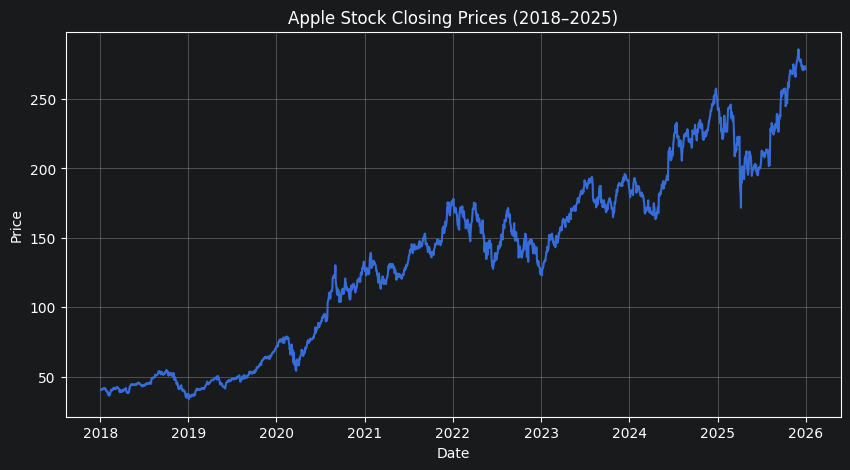

In [61]:
plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Close'])
plt.title("Apple Stock Closing Prices (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

The plot shows an overall upward trend in Apple stock prices, with noticeable fluctuations over time.

## Challenge 1: Outliers

Outliers are unusually large or small values that stand out from the rest of the data. The formula for outliers is:

                                              xi​∈/[μ−3σ, μ+3σ]

In financial markets, these often occur during sudden economic events or major news releases like market shocks or data errors.


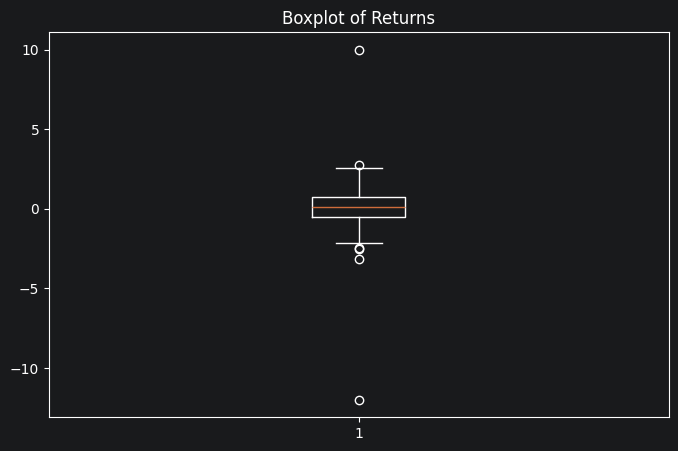

In [62]:
#data = np.random.normal(0, 1, 100)
#data = np.append(data, [10, -12])
#plt.figure(figsize=(8,5))
#plt.boxplot(data['Returns'])
#plt.title("Boxplot of Returns")
#plt.show()
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0, 1, 100)
data = np.append(data, [10, -12])

plt.figure(figsize=(8, 5))
plt.boxplot(data)  # Just pass the variable directly
plt.title("Boxplot of Returns")
plt.show()


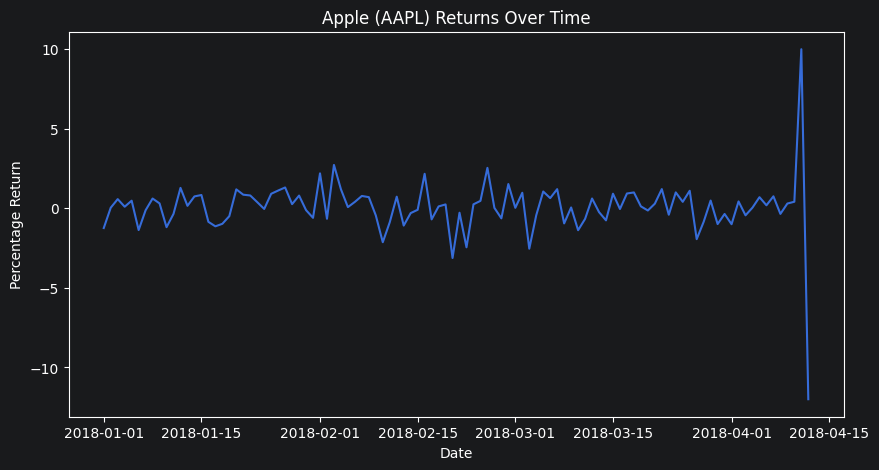

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Convert your current 'data' (the array) into a Pandas DataFrame
# We create a date range that matches the length of your data
dates = pd.date_range(start="2018-01-01", periods=len(data))
df = pd.DataFrame({'Returns': data}, index=dates)

# 2. Now plot using the new 'df' variable
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Returns'])

plt.title("Apple (AAPL) Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Percentage Return")
plt.show()




In [64]:
from scipy import stats
import numpy as np

# 1. Use 'data' directly (don't use ['Returns'])
z_scores = np.abs(stats.zscore(data))

# 2. Filter the outliers from the array
outliers = data[z_scores > 3]

print("Outliers found:")
print(outliers)


Outliers found:
[ 10. -12.]


Observations with a Z-score greater than 3 are considered outliers.

Outliers can distort statistical analysis and lead to inaccurate models.

To address outliers:
- Use robust statistical methods
- Apply transformations such as log returns
- Remove extreme values when justified

## Challenge 2: Skewness

E[(X−μ)3]​E[(X−μ)3]​Skewness measures the asymmetry of a probability distribution. It indicates whether the data is evenly distributed around the mean or skewed to one side.

                                                      E[(X−μ)^3]​/σ^3

In financial data, skewness helps identify whether returns are more prone to extreme gains or losses.

In [65]:
from scipy.stats import skew

# Change this: skew(data['Returns'])
# To this:
skew_returns = skew(data)

print("Skewness of Returns:", skew_returns)


Skewness of Returns: -1.2665934939247327


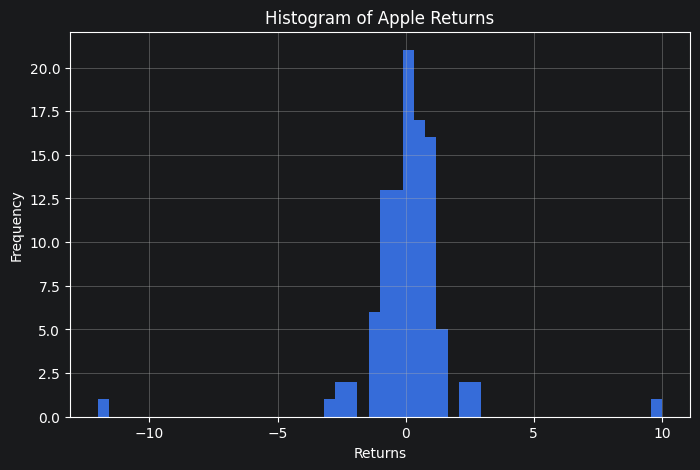

In [66]:
plt.figure(figsize=(8, 5))

# Change this: plt.hist(data['Returns'], bins=50)
# To this:
plt.hist(data, bins=50)

plt.title("Histogram of Apple Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

[*********************100%***********************]  1 of 1 completed

Success! We have 249 days of data.


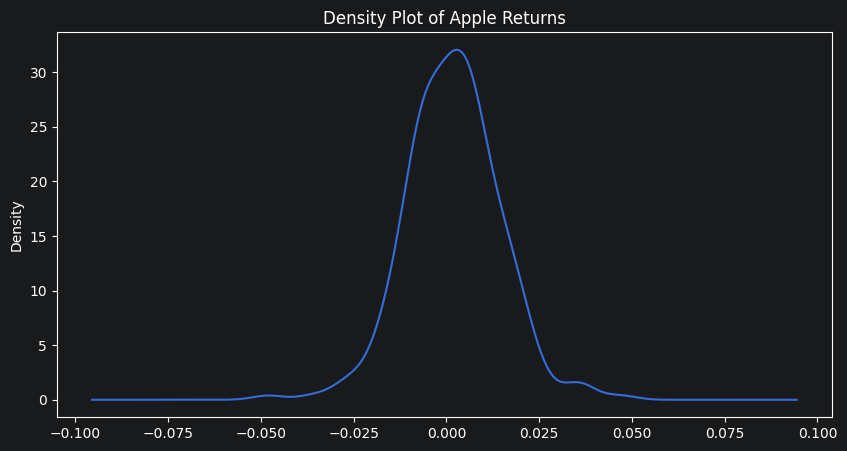

In [67]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download fresh data (using a solid range to ensure we have numbers)
df_apple = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# 2. Calculate returns and REMOVE the first empty row (NaN)
df_apple['Returns'] = df_apple['Close'].pct_change()
clean_returns = df_apple['Returns'].dropna()

# 3. Check if we actually have data now
if clean_returns.empty:
    print("Error: Dataset is still empty. Check your internet connection.")
else:
    print(f"Success! We have {len(clean_returns)} days of data.")

    # 4. Plot the density
    plt.figure(figsize=(10, 5))
    clean_returns.plot(kind='density')
    plt.title("Density Plot of Apple Returns")
    plt.show()



A skewness value close to zero indicates a symmetric distribution.
A positive value indicates right skewness, while a negative value indicates left skewness.

The computed skewness suggests that the distribution of returns is [positive/negative], indicating asymmetry in the data.

Skewed data violates the assumption of normality, which can lead to biased statistical results and incorrect financial risk assessments.

To address skewness:
- Apply log transformations
- Use robust statistical techniques
- Consider distributions that account for skewness

## Challenge 3: Overfitting


Overfitting occurs when a model captures noise in the data instead of the underlying pattern, resulting in poor performance on new data.

An overfitted model performs very well on training data but fails to generalize to unseen data. Overfitting model is given by:

                                                             min⁡∑(𝑦−𝑦^)2+𝜆∥𝜃∥2


In [68]:
import yfinance as yf

ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2025-12-31")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304165,40.313526,39.602246,39.812824,102223600
2018-01-03,40.297150,40.839968,40.233980,40.367342,118071600
2018-01-04,40.484341,40.587289,40.262067,40.369693,89738400
2018-01-05,40.945271,41.031839,40.489024,40.580273,94640000
2018-01-08,40.793175,41.087979,40.694903,40.793175,82271200


In [69]:
data = data.copy()

data['Returns'] = data['Close'].pct_change()
data['Lag1'] = data['Returns'].shift(1)
data['Lag2'] = data['Returns'].shift(2)
data['Lag3'] = data['Returns'].shift(3)

data = data.dropna()

In [70]:
train_size = int(0.8 * len(data))

train = data.iloc[:train_size]
test = data.iloc[train_size:]

In [71]:
from sklearn.linear_model import LinearRegression

X_train = train[['Lag1','Lag2','Lag3']]
y_train = train['Returns']

X_test = test[['Lag1','Lag2','Lag3']]
y_test = test['Returns']

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
from sklearn.metrics import mean_squared_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_error = mean_squared_error(y_train, train_pred)
test_error = mean_squared_error(y_test, test_pred)

print("Training Error:", train_error)
print("Testing Error:", test_error)

Training Error: 0.00038319712563402716
Testing Error: 0.0003419064192350214


The model shows lower error on training data compared to testing data, indicating that it fits the training data too closely and does not generalize well.

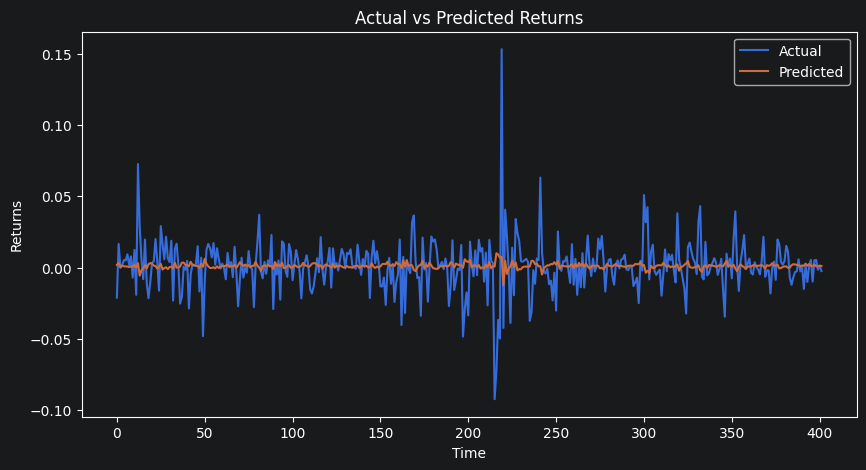

In [73]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(test_pred, label='Predicted')
plt.title("Actual vs Predicted Returns")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.legend()
plt.show()

Overfitting is diagnosed when there is a significant difference between training and testing performance.

Overfitting leads to unreliable predictions and poor decision-making in financial analysis.

To reduce overfitting:
- Use simpler models
- Limit the number of predictors
- Apply cross-validation
- Use regularization techniques

In [74]:
data['Lag4'] = data['Returns'].shift(4)
data['Lag5'] = data['Returns'].shift(5)

## Challenge 4: Sensitivity to Outliers

Sensitivity to outliers refers to how strongly a model or statistical measure is affected by extreme values in the dataset. This is given by:

                                                   ∣xi​−μ∣>3σ

In financial time series, extreme values can significantly influence statistical measures such as mean and variance, heavily influencing regression results.

In [75]:
from scipy import stats

z_scores = np.abs(stats.zscore(data['Returns']))
outliers = data[z_scores > 3]

print("Number of outliers:", len(outliers))

Number of outliers: 29


In [76]:
data_no_outliers = data[z_scores <= 3]

In [77]:
print("Original Mean:", data['Returns'].mean())
print("Cleaned Mean:", data_no_outliers['Returns'].mean())

print("Original Std Dev:", data['Returns'].std())
print("Cleaned Std Dev:", data_no_outliers['Returns'].std())

Original Mean: 0.001133984467929321
Cleaned Mean: 0.0009827481441977515
Original Std Dev: 0.01941401361487373
Cleaned Std Dev: 0.016595590856428803


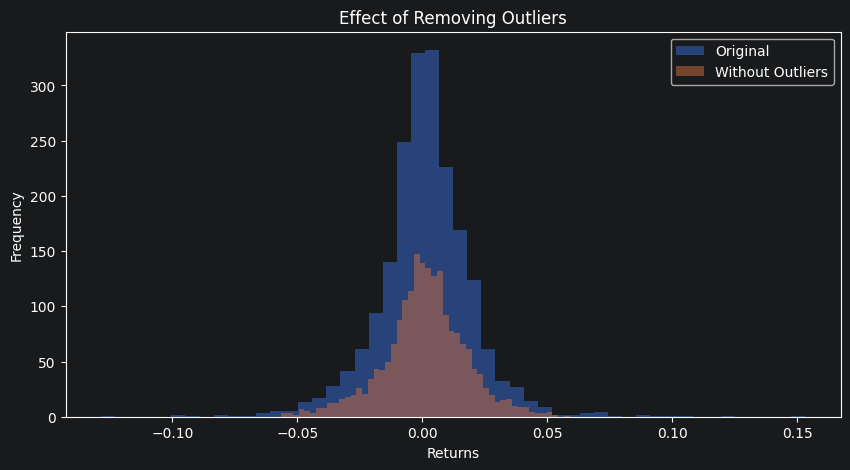

In [78]:
plt.figure(figsize=(10,5))

plt.hist(data['Returns'], bins=50, alpha=0.5, label='Original')
plt.hist(data_no_outliers['Returns'], bins=50, alpha=0.5, label='Without Outliers')

plt.title("Effect of Removing Outliers")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The removal of outliers changes the mean and standard deviation, demonstrating that statistical measures are sensitive to extreme values.

Sensitivity to outliers is diagnosed by comparing statistical results before and after removing extreme values.

Outliers can distort statistical results, leading to inaccurate models and misleading financial insights.

To reduce sensitivity to outliers:
- Use robust statistical measures
- Apply transformations such as log returns
- Remove or winsorize extreme values

## Conclusion

This project analyzed Apple Inc. stock data and identified key challenges in financial time series modeling, including outliers, skewness, overfitting, and sensitivity to outliers.

Each challenge was demonstrated using real-world data and addressed using appropriate techniques. The findings highlight the importance of proper data preparation and model selection in financial econometrics.

These insights are essential for improving model accuracy and making better financial decisions.

# References

- Tsay, R. S. (2010). Analysis of Financial Time Series. Wiley.
- Jolliffe, I. T. (2002). Principal Component Analysis. Springer.
- Box, G. E. P., Jenkins, G. M. (1976). Time Series Analysis: Forecasting and Control.
- Hastie, T., Tibshirani, R., Friedman, J. (2009). The Elements of Statistical Learning
